# **Código usado por el grupo A para el APE 04**

# Generación de momentos con scipy.stats

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import binom, norm

# Carga de datos real
df_regional = pd.read_csv('dataset_pandas_grupoA.csv', sep=';', thousands='.', header=2)
df_regional.rename(columns={df_regional.columns[0]: 'Edad'}, inplace=True)
df_regional = df_regional[df_regional['Edad'] != 'Total']

# 1. Variable Aleatoria Discreta (Basada en la frecuencia de un grupo)
# Ejemplo: Probabilidad de éxito p calculada como la proporción de un rango específico
total_mujeres = df_regional['Mujer'].sum()
n_ensayos = 10
p_exito = df_regional.iloc[0]['Mujer'] / total_mujeres # Proporción del primer rango
var_discreta = binom(n_ensayos, p_exito)

# Cálculo de Momentos Teóricos (Mean, Variance)
esperanza_d, varianza_d = var_discreta.stats(moments='mv')
print(f"--- Variable Discreta (Binomial n={n_ensayos}, p={p_exito:.4f}) ---")
print(f"Esperanza E[X]: {esperanza_d:.2f}")
print(f"Varianza V[X]: {varianza_d:.2f}\n")

# 2. Variable Aleatoria Continua (Distribución Normal basada en tus datos)
# Usamos la media y desviación real de tu columna 'Mujer'
mu = df_regional['Mujer'].mean()
sigma = df_regional['Mujer'].std()
var_continua = norm(loc=mu, scale=sigma)

esperanza_c, varianza_c = var_continua.stats(moments='mv')
print(f"--- Variable Continua (Normal mu={mu:.2f}, sigma={sigma:.2f}) ---")
print(f"Esperanza E[X]: {esperanza_c:.2f}")
print(f"Varianza V[X]: {varianza_c:.2f}")

--- Variable Discreta (Binomial n=10, p=0.0090) ---
Esperanza E[X]: 0.09
Varianza V[X]: 0.09

--- Variable Continua (Normal mu=10190.62, sigma=9489.45) ---
Esperanza E[X]: 10190.62
Varianza V[X]: 90049650.25


# Trabajo del dataset elegido con el uso de Pandas

Análisis del Dataset Regional - Variable: Mujer
Media Muestral (Estimador de E[X]): 10190.62
Varianza Muestral (Estimador de V[X]): 90049650.25


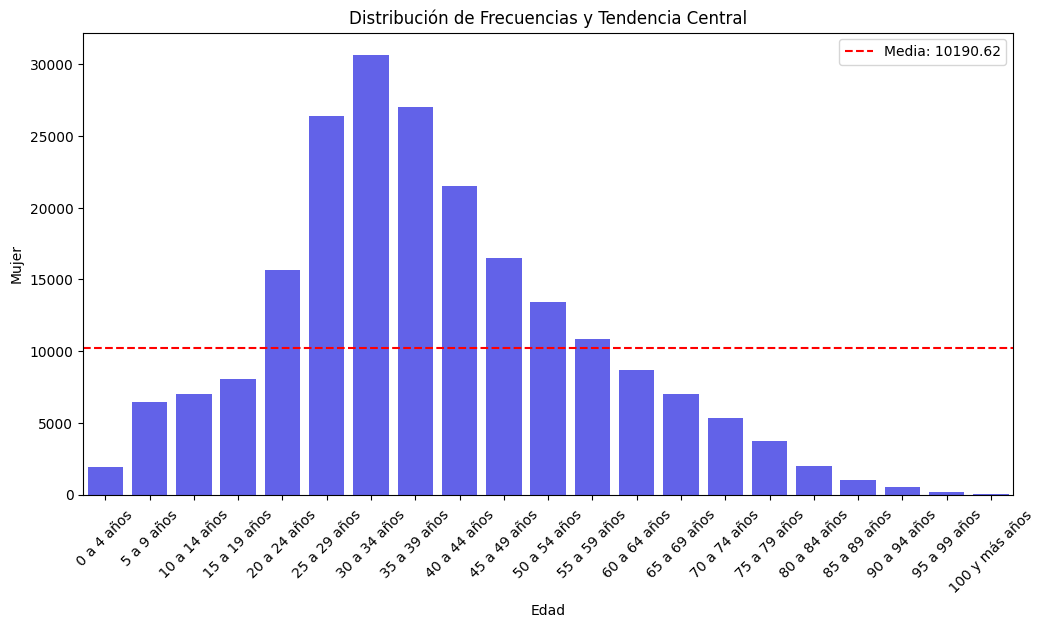

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carga de datos (/content/dataset_pandas_grupoA.csv)
df_regional = pd.read_csv('dataset_pandas_grupoA.csv', sep=';', thousands='.', header=2)
df_regional.rename(columns={df_regional.columns[0]: 'Edad'}, inplace=True)
df_regional = df_regional[df_regional['Edad'] != 'Total']

# SIMULACIÓN (A falta del dataset real en esta guía, usamos datos simulados para ilustrar)
# (Se utilizan los datos cargados del CSV superior)

# Cálculo de Estadísticos usando Pandas
columna_obj = 'Mujer'
media_muestral = df_regional[columna_obj].mean()
varianza_muestral = df_regional[columna_obj].var(ddof=1) # ddof=1 para muestra insesgada

print(f"Análisis del Dataset Regional - Variable: {columna_obj}")
print(f"Media Muestral (Estimador de E[X]): {media_muestral:.2f}")
print(f"Varianza Muestral (Estimador de V[X]): {varianza_muestral:.2f}")

# Visualización para el hito del proyecto
plt.figure(figsize=(12, 6))
sns.barplot(data=df_regional, x='Edad', y=columna_obj, color='blue', alpha=0.7)
plt.axhline(media_muestral, color='red', linestyle='--', label=f'Media: {media_muestral:.2f}')
plt.title('Distribución de Frecuencias y Tendencia Central')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Uso de ddof = 1 en Pandas
## El ddof significa delta degree of fredoom, que se refiere a los grados de libertad, lo que se utiliza para la varianza muestral. La razón para usar ddof = 1 es que es el divisor de la fórmula de la varianza, interpretándose como N-1, lo que se conoce como un estimador insesgado de la varianza muestral, un elemento estadístico cuyo valor es exactamente igual al parámetro real de la población que se desea medir. Esto da como resultado una garantía de que no haya errores a la hora de hacer los cálculos, al no sobreestimar o subestimar los valores reales.